## 1.1 Background

Municipal energy systems combine electricity production, district heating production, and final energy use. Public statistics provide multi-year observations at municipal level, enabling comparisons across locations and time.


## 1.2 Problem Definition

Some municipalities deviate from typical energy system structures due to differences in industry, infrastructure, and local supply. The challenge is to identify municipalities whose joint patterns of production and use are unusual in a multivariate sense.

## 1.3 Research Question

Research question: Can unsupervised anomaly detection identify municipalities with atypical energy production and consumption patterns?

We apply two methods: Isolation Forest and an autoencoder. The autoencoder learns to reconstruct (predict) each municipality-year feature vector; unusually high reconstruction error indicates anomalies.

## 1.4 Scope & Data Assumptions

The analysis is performed at municipality–year level using three SCB domains: electricity production, district heating production, and final energy use (2005–2023). Values marked “..” are treated as missing; zeros are kept as valid observations. All tables are harmonized and merged on municipality and year before modeling.

# 2. Dataset Description

Data comes from Statistics Sweden (SCB) municipal energy statistics (2005–2023). We use three domains: final energy use, electricity production, and district heating production. The data is provided as six CSV files (2005–2008 and 2009–2023 per domain) and integrated at municipality–year level.

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Set project paths (works on Windows/Mac/Linux) ---
PROJECT_ROOT = Path.cwd()                 # notebook folder
DATA_DIR = PROJECT_ROOT / "data"          # if notebook is in repo root

# If your notebook is inside another folder, use this instead:
# DATA_DIR = PROJECT_ROOT.parent / "data"

# Quick check
print("Notebook folder:", PROJECT_ROOT)
print("Data folder exists:", DATA_DIR.exists())
print("Files in data:", len(list(DATA_DIR.glob("*.csv"))))

# --- Load files by filename endings (safer than hardcoding full names) ---
PATHS = {
    "use_0508":  next(DATA_DIR.glob("Slutanvändning*2005 - 2008.csv")),
    "use_0923":  next(DATA_DIR.glob("Slutanvändning*2009 - 2023.csv")),
    "el_0508":   next(DATA_DIR.glob("Elproduktion*2005 - 2008.csv")),
    "el_0923":   next(DATA_DIR.glob("Elproduktion*2009 - 2023.csv")),
    "heat_0508": next(DATA_DIR.glob("Fjärrvärmeproduktion*2005 - 2008.csv")),
    "heat_0923": next(DATA_DIR.glob("Fjärrvärmeproduktion*2009 - 2023.csv")),
}

# SCB CSVs often use latin1
raw = {k: pd.read_csv(str(v), encoding="latin1") for k, v in PATHS.items()}

overview = pd.DataFrame(
    [(k, df.shape[0], df.shape[1]) for k, df in raw.items()],
    columns=["dataset", "rows", "cols"]
).sort_values("dataset")

overview

Notebook folder: C:\Users\robin\Energy-consumption
Data folder exists: True
Files in data: 6


,dataset,rows,cols
2,el_0508,45072,5
3,el_0923,224640,5
4,heat_0508,78876,5
5,heat_0923,262080,5
0,use_0508,112680,5
1,use_0923,379080,5


# 3. Data Preparation

This section prepares the datasets for analysis. The goal is to inspect the raw data, handle suppressed values, and transform the datasets into a consistent structure suitable for analysis.

The datasets are inspected to understand their dimensions and column structure before applying preprocessing steps.

## 3.1 Initial Data Inspection

The datasets are first inspected to verify their dimensions, column structure, and general formatting. This step ensures that the datasets were loaded correctly and provides an overview of the variables available for analysis.

In [7]:
for k, df in raw.items():
    print("\n---", k, "---")
    display(df.head(3))


--- use_0508 ---


,region,förbrukarkategori,bränsletyp,år,Slutanvändning (MWh)
0,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2005,4195950
1,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2006,4158066
2,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2007,3689400



--- use_0923 ---


,region,förbrukarkategori,bränsletyp,år,Slutanvändning (MWh)
0,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2009,3563159
1,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2010,3697521
2,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2011,3394844



--- el_0508 ---


...

,region,produktionssätt,bränsletyp,år,Elproduktion och bränsleanvändning (MWh)
0,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2009,15822643
1,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2010,18905397
2,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2011,16881147



--- heat_0508 ---


,region,produktionssätt,bränsletyp,år,Fjärrvärmeproduktion och bränsleanvändning (MWh)
0,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2005,28878151
1,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2006,31540649
2,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2007,30934340



--- heat_0923 ---


,region,produktionssätt,bränsletyp,år,Fjärrvärmeproduktion och bränsleanvändning (MWh)
0,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2009,28956094
1,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2010,33352707
2,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2011,..


## 3.2 Handling Suppressed Values

In the datasets, suppressed values are represented by the symbol "..". These values indicate missing or confidential data and cannot be interpreted as numerical observations.

To ensure correct numerical processing, these values are replaced with NaN before further transformations are applied.

In [8]:
def standardize_scb(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df.copy()

    # Rename to internal standard names
    out = out.rename(columns={"år": "year"})

    # Replace suppressed values
    out[value_col] = out[value_col].replace("..", np.nan)

    # Numeric
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")

    # Strip text columns
    for c in out.columns:
        if out[c].dtype == "object":
            out[c] = out[c].astype(str).str.strip()

    return out

use_val  = "Slutanvändning (MWh)"
el_val   = "Elproduktion och bränsleanvändning (MWh)"
heat_val = "Fjärrvärmeproduktion och bränsleanvändning (MWh)"

use_0508  = standardize_scb(raw["use_0508"],  use_val)
use_0923  = standardize_scb(raw["use_0923"],  use_val)
el_0508   = standardize_scb(raw["el_0508"],   el_val)
el_0923   = standardize_scb(raw["el_0923"],   el_val)
heat_0508 = standardize_scb(raw["heat_0508"], heat_val)
heat_0923 = standardize_scb(raw["heat_0923"], heat_val)

pd.DataFrame({
    "dataset": ["use_0508","use_0923","el_0508","el_0923","heat_0508","heat_0923"],
    "missing_after_dots": [
        use_0508[use_val].isna().sum(),
        use_0923[use_val].isna().sum(),
        el_0508[el_val].isna().sum(),
        el_0923[el_val].isna().sum(),
        heat_0508[heat_val].isna().sum(),
        heat_0923[heat_val].isna().sum(),
    ]
})

,dataset,missing_after_dots
0,use_0508,10975
1,use_0923,33283
2,el_0508,1997
3,el_0923,44262
4,heat_0508,1232
5,heat_0923,9253


## 3.3 Structural Transformation

The datasets are originally stored in a wide format where years are represented as columns. For analysis, the datasets are transformed into a long format where each row represents a municipality–year observation.

This transformation simplifies temporal analysis and enables merging the datasets across common identifiers.

In [9]:
use_all  = pd.concat([use_0508, use_0923], ignore_index=True)
el_all   = pd.concat([el_0508, el_0923], ignore_index=True)
heat_all = pd.concat([heat_0508, heat_0923], ignore_index=True)

use_all.shape, el_all.shape, heat_all.shape

((491760, 5), (269712, 5), (340956, 5))

## 3.4 Dataset Integration

After transforming the datasets into a consistent structure, they are merged into a single dataset using municipality and year as common keys.

This integrated dataset enables joint analysis of electricity production, fuel consumption, and district heating within the same municipal energy system.

In [19]:
# A) Final energy use: keep TOTAL fuel only
use_tot = use_all[use_all["bränsletyp"].str.lower().isin(["totalt", "total"])].copy()

use_wide = use_tot.pivot_table(
    index=["region", "year"],
    columns="förbrukarkategori",
    values=use_val,
    aggfunc="sum"
)

# B) Electricity: sum over fuel types per production method
el_wide = el_all.pivot_table(
    index=["region", "year"],
    columns="produktionssätt",
    values=el_val,
    aggfunc="sum"
)

# C) District heating: sum over fuel types per production method
heat_wide = heat_all.pivot_table(
    index=["region", "year"],
    columns="produktionssätt",
    values=heat_val,
    aggfunc="sum"
)

# Prefix to avoid collisions
use_wide.columns  = [f"use__{c}" for c in use_wide.columns]
el_wide.columns   = [f"el__{c}" for c in el_wide.columns]
heat_wide.columns = [f"heat__{c}" for c in heat_wide.columns]

df_merged = (
    use_wide
    .join(el_wide, how="outer")
    .join(heat_wide, how="outer")
    .reset_index()
)

df_merged.head(), df_merged.shape

(     region  year  use__slutanv. flerbostadshus  use__slutanv. fritidshus  \
 0  00 Riket  2005                    32316972.0                 2374461.0   
 1  00 Riket  2006                    30200411.0                 2366857.0   
 2  00 Riket  2007                    30476844.0                 2173179.0   
 3  00 Riket  2008                    29419643.0                 2755490.0   
 4  00 Riket  2009                    29098990.0                       0.0   
 
    use__slutanv. industri, byggverks.  use__slutanv. jordbruk,skogsbruk,fiske  \
 0                                 0.0                               8045235.0   
 1                         184638881.0                               7398037.0   
 2                         180951875.0                               6551526.0   
 3                         176051629.0                               6917673.0   
 4                                 0.0                               6562052.0   
 
    use__slutanv. offentlig verksamh

In [20]:
print("Rows:", df_merged.shape[0], "Cols:", df_merged.shape[1])
print("Year range:", int(df_merged["year"].min()), "-", int(df_merged["year"].max()))
print("Missing cells:", int(df_merged.isna().sum().sum()))

Rows: 5932 Cols: 24
Year range: 2005 - 2023
Missing cells: 2504


In [21]:
df_merged = df_merged[df_merged["region"].str.lower() != "00 riket"].copy()
print("Rows after removing Riket:", df_merged.shape[0])

Rows after removing Riket: 5913


In [22]:
(df_merged.drop(columns=["region","year"]) == 0).sum().sort_values(ascending=False).head(10)

el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)    5430
heat__värmepumpar (2)                                    5226
heat__elpannor (1)                                       4784
heat__kraftvärmeverk                                     4256
heat__spillvärme                                         4120
el__kraftvärmeverk + industriellt mottryck               3855
el__solkraft                                             3732
el__vindkraft                                            3617
heat__rökgaskondens                                      3203
el__vattenkraft                                          3043
dtype: int64

# 4. Feature Engineering

## 4.1 Feature matrix setup

Create the municipality–year feature matrix. region and year are identifiers and excluded from model input.

In [23]:
# 4.1 Feature matrix setup (municipality-only)
df = df_merged.copy()

# Keep only municipalities (4-digit municipality code at the start, e.g., "1480 Göteborg")
df = df[df["region"].str.match(r"^\d{4}\s", na=False)].copy()

# Safety: remove national aggregate if present
df = df[df["region"].str.lower() != "00 riket"].copy()

df = df.sort_values(["region", "year"]).reset_index(drop=True)

feature_cols = [c for c in df.columns if c not in ["region", "year"]]
X_raw = df[feature_cols].copy()

print("Rows:", df.shape[0], "Features:", len(feature_cols))
print("Unique municipalities:", df["region"].nunique())
print("Missing cells:", int(X_raw.isna().sum().sum()))

Rows: 5514 Features: 22
Unique municipalities: 291
Missing cells: 2328


## 4.2 Missingness handling (suppressed values)

Values marked “..” were converted to NaN. We (1) create missing indicators and (2) impute NaN with 0 to keep a consistent feature space.

In [24]:
# 4.2 Missingness handling
miss_ind = X_raw.isna().astype(int)
miss_ind.columns = [f"miss__{c}" for c in miss_ind.columns]

X_imp = X_raw.fillna(0)

X_fe = pd.concat([X_imp, miss_ind], axis=1)
print("Feature engineering shape:", X_fe.shape)

Feature engineering shape: (5514, 44)


## 4.3 Distribution stabilization (log transform)

Energy variables are highly skewed. We apply log1p to stabilize scale while keeping zeros valid.

In [25]:
# 4.3 Log transform
X_log = np.log1p(X_fe)

## 4.4 Scaling for modeling

Autoencoders benefit from scaling. We use RobustScaler to reduce sensitivity to extreme values.

In [26]:
# 4.4 Scaling for modeling (fit on train only to avoid leakage)
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

In [27]:
ids = df[["region", "year"]].copy()

In [28]:
feature_cols = [c for c in df_merged.columns if c not in ["region", "year"]]

cols_0508 = set(df_merged.loc[df_merged["year"].between(2005, 2008), feature_cols].columns)
cols_0923 = set(df_merged.loc[df_merged["year"].between(2009, 2023), feature_cols].columns)

print("Features 2005–2008:", len(cols_0508))
print("Features 2009–2023:", len(cols_0923))
print("In 05–08 but not 09–23:", sorted(list(cols_0508 - cols_0923))[:50])
print("In 09–23 but not 05–08:", sorted(list(cols_0923 - cols_0508))[:50])

Features 2005–2008: 22
Features 2009–2023: 22
In 05–08 but not 09–23: []
In 09–23 but not 05–08: []


After concatenation and pivoting, the feature space is consistent across 2005–2008 and 2009–2023 (22 features in both periods; no period-specific columns).

# 5. Exploratory Data Analysis

## 5.1 Feature Distributions

Energy variables are right-skewed and many features contain zeros. This motivates log1p and robust scaling before modeling.

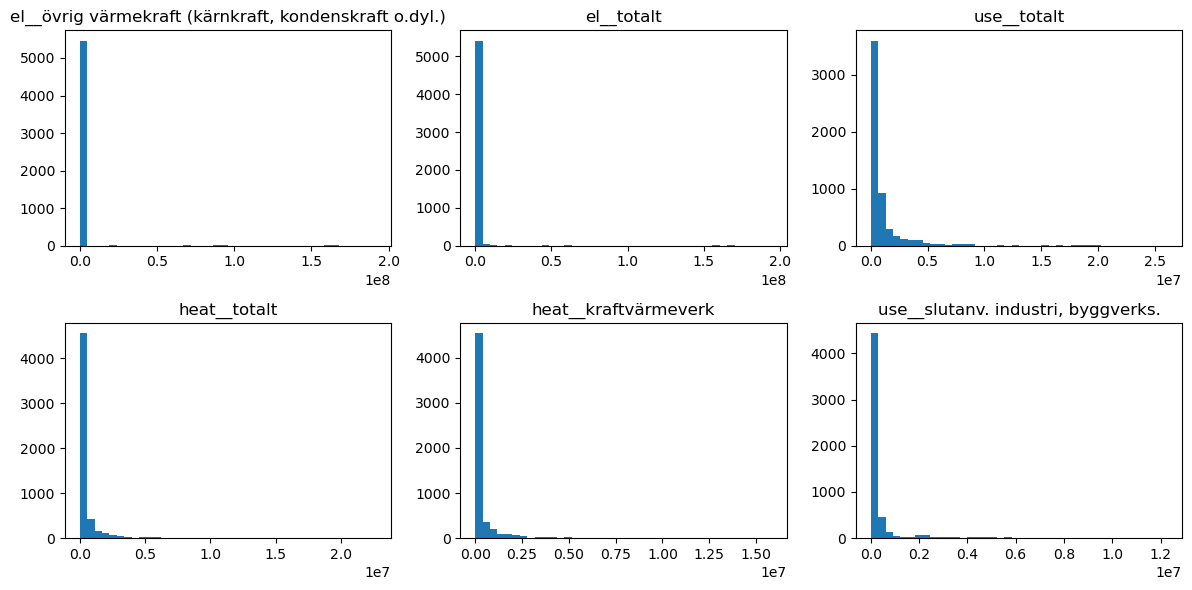

In [41]:
import matplotlib.pyplot as plt

# Choose a few representative features (highest variance is a simple heuristic)
X_show = X_raw.copy()
top_feats = X_show.var(numeric_only=True).sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

for ax, col in zip(axes, top_feats):
    vals = X_show[col].dropna()
    ax.hist(vals, bins=40)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [42]:
zero_rate = (X_imp == 0).mean().sort_values(ascending=False)
zero_rate.head(10)

el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)    0.948495
heat__värmepumpar (2)                                    0.916032
heat__elpannor (1)                                       0.844033
el__vindkraft                                            0.842220
el__solkraft                                             0.842220
heat__kraftvärmeverk                                     0.763330
heat__spillvärme                                         0.735401
el__kraftvärmeverk + industriellt mottryck               0.697135
heat__rökgaskondens                                      0.563293
el__vattenkraft                                          0.535002
dtype: float64

## 5.2 Correlation Analysis

Correlations indicate shared structure within and across domains (use, electricity, district heating). This supports a multivariate approach.

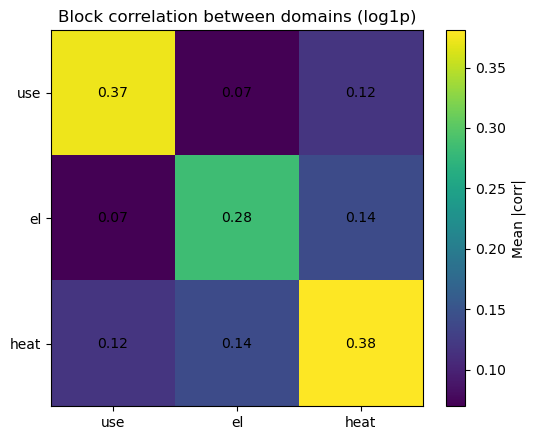

,use,el,heat
use,0.372525,0.069762,0.118218
el,0.069762,0.283859,0.141327
heat,0.118218,0.141327,0.380783


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Correlation on log1p(imputed) of ORIGINAL features (no missing-indicators)
X_corr = np.log1p(X_imp.copy())
C = X_corr.corr()

use_cols  = [c for c in X_imp.columns if c.startswith("use__")]
el_cols   = [c for c in X_imp.columns if c.startswith("el__")]
heat_cols = [c for c in X_imp.columns if c.startswith("heat__")]

groups = [("use", use_cols), ("el", el_cols), ("heat", heat_cols)]

# Mean absolute correlation between groups
block = pd.DataFrame(index=[g[0] for g in groups], columns=[g[0] for g in groups], dtype=float)
for gi, cols_i in groups:
    for gj, cols_j in groups:
        block.loc[gi, gj] = C.loc[cols_i, cols_j].abs().values.mean()

plt.figure(figsize=(5.5, 4.5))
plt.imshow(block.values, aspect="auto")
plt.colorbar(label="Mean |corr|")
plt.xticks(range(len(block.columns)), block.columns)
plt.yticks(range(len(block.index)), block.index)
plt.title("Block correlation between domains (log1p)")

# NEW: print values inside the cells
for i in range(block.shape[0]):
    for j in range(block.shape[1]):
        plt.text(j, i, f"{block.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

block

In [44]:
pairs = (
    C.where(~np.eye(C.shape[0], dtype=bool))
     .stack()
     .abs()
     .sort_values(ascending=False)
     .head(15)
)
pairs

heat__kraftvärmeverk                        el__kraftvärmeverk + industriellt mottryck    0.779055
el__kraftvärmeverk + industriellt mottryck  heat__kraftvärmeverk                          0.779055
heat__totalt                                heat__fristående värmeverk                    0.730357
heat__fristående värmeverk                  heat__totalt                                  0.730357
use__slutanv. offentlig verksamhet          use__slutanv. flerbostadshus                  0.712582
use__slutanv. flerbostadshus                use__slutanv. offentlig verksamhet            0.712582
use__slutanv. offentlig verksamhet          use__slutanv. övriga tjänster                 0.612068
use__slutanv. övriga tjänster               use__slutanv. offentlig verksamhet            0.612068
                                            use__slutanv. flerbostadshus                  0.589002
use__slutanv. flerbostadshus                use__slutanv. övriga tjänster                 0.589002
use__total

## 5.3 Missingness pattern

Missing values mainly come from suppressed entries (“..”). We preserve this information using missing indicators.

In [45]:
missing_rate = X_raw.isna().mean().sort_values(ascending=False)
missing_rate[missing_rate > 0].head(10)

el__solkraft     0.211099
el__vindkraft    0.211099
dtype: float64

# 6. Modeling Strategy (Train/Validation/Test & Metrics)

## 6.1 Time-based split

Markdown:
We use a time-based split to reduce leakage across years: train (2005–2018), validation (2019–2020), test (2021–2023).

In [29]:
# 6.1 Time-based split
train_years = (2005, 2018)
val_years   = (2019, 2020)
test_years  = (2021, 2023)

idx_train = df["year"].between(*train_years)
idx_val   = df["year"].between(*val_years)
idx_test  = df["year"].between(*test_years)

# Fit scaler on TRAIN only, then transform val/test
X_train = scaler.fit_transform(X_log.loc[idx_train])
X_val   = scaler.transform(X_log.loc[idx_val])
X_test  = scaler.transform(X_log.loc[idx_test])

ids_train = ids.loc[idx_train].reset_index(drop=True)
ids_val   = ids.loc[idx_val].reset_index(drop=True)
ids_test  = ids.loc[idx_test].reset_index(drop=True)

print("Train:", X_train.shape, "Years:", train_years)
print("Val:  ", X_val.shape,   "Years:", val_years)
print("Test: ", X_test.shape,  "Years:", test_years)

Train: (4064, 44) Years: (2005, 2018)
Val:   (580, 44) Years: (2019, 2020)
Test:  (870, 44) Years: (2021, 2023)


## 6.2 Leakage check and basic sanity

Markdown:
We verify that splits are disjoint and that no NaNs remain in the model inputs.

In [47]:
# 6.2 Sanity checks
import numpy as np

assert (idx_train & idx_val).sum() == 0
assert (idx_train & idx_test).sum() == 0
assert (idx_val & idx_test).sum() == 0

print("NaNs in train/val/test:",
      int(np.isnan(X_train).sum()),
      int(np.isnan(X_val).sum()),
      int(np.isnan(X_test).sum()))

print("Unique regions (train/val/test):",
      ids_train["region"].nunique(),
      ids_val["region"].nunique(),
      ids_test["region"].nunique())

NaNs in train/val/test: 0 0 0
Unique regions (train/val/test): 291 290 290


## 6.3 Model evaluation plan

Isolation Forest is fit on the training set and scored on all splits. The autoencoder is trained on the training set with validation-based early stopping; anomalies are defined by high reconstruction error. We report top-ranked anomalies per year and compare stability across splits.

# 7. Modeling

## 7.1 Isolation Forest

In [48]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import numpy as np

# Train Isolation Forest on training period only
iforest = IsolationForest(
    n_estimators=500,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)
iforest.fit(X_train)

def iforest_scores(model, X, ids_df):
    # decision_function: higher = more normal
    # anomaly score: higher = more anomalous
    normality = model.decision_function(X)
    anomaly_score = -normality
    out = ids_df.copy()
    out["iforest_anomaly_score"] = anomaly_score
    out = out.sort_values("iforest_anomaly_score", ascending=False).reset_index(drop=True)
    return out

if_train = iforest_scores(iforest, X_train, ids_train)
if_val   = iforest_scores(iforest, X_val, ids_val)
if_test  = iforest_scores(iforest, X_test, ids_test)

if_test.head(10)

,region,year,iforest_anomaly_score
0,0180 Stockholm,2021,0.192254
1,1480 Göteborg,2022,0.167159
2,0980 Gotland,2021,0.157796
3,0180 Stockholm,2022,0.156952
4,0180 Stockholm,2023,0.143255
5,0380 Uppsala,2021,0.135191
6,1494 Lidköping,2023,0.132014
7,1480 Göteborg,2021,0.122484
8,1480 Göteborg,2023,0.117809
9,2580 Luleå,2021,0.110092


In [50]:
topk = 5
if_test_top = (
    if_test.sort_values(["year", "iforest_anomaly_score"], ascending=[True, False])
          .groupby("year")
          .head(topk)
          .reset_index(drop=True)
)
if_test_top

,region,year,iforest_anomaly_score
0,0180 Stockholm,2021,0.192254
1,0980 Gotland,2021,0.157796
2,0380 Uppsala,2021,0.135191
3,1480 Göteborg,2021,0.122484
4,2580 Luleå,2021,0.110092
5,1480 Göteborg,2022,0.167159
6,0180 Stockholm,2022,0.156952
7,2580 Luleå,2022,0.108940
8,0380 Uppsala,2022,0.105387
9,2482 Skellefteå,2022,0.105216


## 7.2 Autoencoder

The autoencoder learns to reconstruct typical municipality–year energy profiles. Observations with high reconstruction error are treated as anomalies. Training is performed on 2005–2018 with validation-based early stopping (2019–2020).

In [52]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

input_dim = X_train.shape[1]

def build_autoencoder(input_dim: int) -> keras.Model:
    inp = keras.Input(shape=(input_dim,))
    
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.Dense(16, activation="relu")(x)
    bottleneck = layers.Dense(8, activation="relu")(x)

    x = layers.Dense(16, activation="relu")(bottleneck)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(input_dim, activation="linear")(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

ae = build_autoencoder(input_dim)
ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 44)             │         1,452 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,244 (16.58 KB)

 Trainable params: 4,244 (16.58 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = ae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=200,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.9183 - val_loss: 3.3371
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7593 - val_loss: 3.1195
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4372 - val_loss: 2.6479
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9546 - val_loss: 2.1372
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5783 - val_loss: 1.8339
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3366 - val_loss: 1.6049
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1641 - val_loss: 1.4057
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0314 - val_loss: 1.2458
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9428 - val_loss: 1.1332
Epoch 10/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8742 - val_loss: 1.0413
Epoch 11/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8195 - val_loss: 0.9818
Epoch 12/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

Reconstruction error is computed as mean squared error per observation and used to rank anomalies.

In [54]:
import numpy as np
import pandas as pd

def recon_error(model, X):
    X_hat = model.predict(X, verbose=0)
    err = np.mean((X - X_hat) ** 2, axis=1)  # MSE per row
    return err

ae_train_err = recon_error(ae, X_train)
ae_val_err   = recon_error(ae, X_val)
ae_test_err  = recon_error(ae, X_test)

print("Reconstruction error (mean) train/val/test:",
      float(ae_train_err.mean()),
      float(ae_val_err.mean()),
      float(ae_test_err.mean()))

Reconstruction error (mean) train/val/test: 0.11070763991556938 0.16862967016546893 3.1734854874605585


In [55]:
ae_test = ids_test.copy()
ae_test["ae_recon_error"] = ae_test_err
ae_test = ae_test.sort_values("ae_recon_error", ascending=False).reset_index(drop=True)

ae_test.head(10)

,region,year,ae_recon_error
0,0483 Katrineholm,2022,9.899772
1,1980 Västerås,2022,9.749165
2,0381 Enköping,2022,9.190154
3,0380 Uppsala,2021,8.673395
4,0381 Enköping,2021,8.373954
5,1981 Sala,2022,8.215761
6,2180 Gävle,2022,8.176779
7,0484 Eskilstuna,2022,8.029326
8,1480 Göteborg,2021,7.827572
9,2380 Östersund,2021,7.012802


In [57]:
topk = 5
ae_test_top = (
    ae_test.sort_values(["year", "ae_recon_error"], ascending=[True, False])
           .groupby("year")
           .head(topk)
           .reset_index(drop=True)
)
ae_test_top

,region,year,ae_recon_error
0,0380 Uppsala,2021,8.673395
1,0381 Enköping,2021,8.373954
2,1480 Göteborg,2021,7.827572
3,2380 Östersund,2021,7.012802
4,1482 Kungälv,2021,6.724579
5,0483 Katrineholm,2022,9.899772
6,1980 Västerås,2022,9.749165
7,0381 Enköping,2022,9.190154
8,1981 Sala,2022,8.215761
9,2180 Gävle,2022,8.176779


### 7.3 Agreement between methods (Overlap)

We compare the top-ranked anomalies from Isolation Forest and the autoencoder to assess stability across methods.

In [58]:
# merge top lists (test only) to see overlap
if_test_rank = if_test.copy()
...
both_top

,region,year,iforest_anomaly_score,if_rank,ae_recon_error,ae_rank
60,0483 Katrineholm,2022,0.050998,61,9.899772,1
16,1980 Västerås,2022,0.094741,17,9.749165,2
114,0381 Enköping,2022,0.029928,115,9.190154,3
5,0380 Uppsala,2021,0.135191,6,8.673395,4
127,0381 Enköping,2021,0.023489,128,8.373954,5
85,1981 Sala,2022,0.041187,86,8.215761,6
29,2180 Gävle,2022,0.084272,30,8.176779,7
157,0484 Eskilstuna,2022,0.016159,158,8.029326,8
7,1480 Göteborg,2021,0.122484,8,7.827572,9
62,2380 Östersund,2021,0.050677,63,7.012802,10


# 8. Evaluation

## 8.1 Model Behaviour

We inspect score distributions across train/validation/test and define anomalies using a threshold derived from the training distribution
We also report a validation-based threshold for the autoencoder to account for temporal shift.

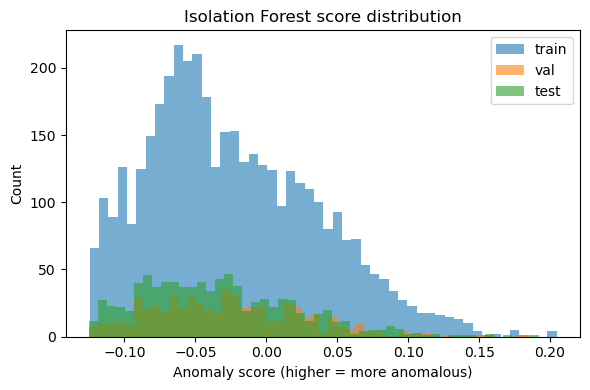

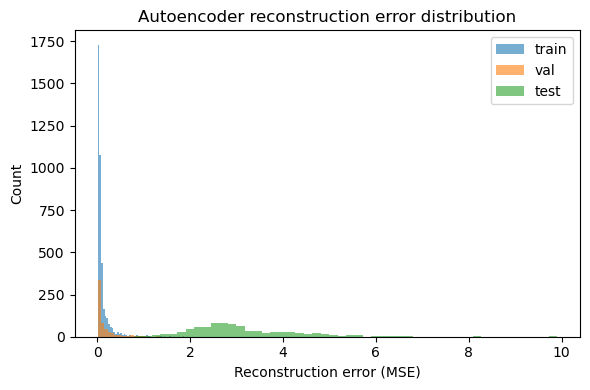

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Collect scores ---
if_scores = pd.concat([
    if_train.assign(split="train"),
    if_val.assign(split="val"),
    if_test.assign(split="test")
], ignore_index=True)

ae_train = ids_train.copy(); ae_train["ae_recon_error"] = ae_train_err; ae_train["split"] = "train"
ae_val   = ids_val.copy();   ae_val["ae_recon_error"]   = ae_val_err;   ae_val["split"]   = "val"
ae_test2 = ids_test.copy();  ae_test2["ae_recon_error"] = ae_test_err;  ae_test2["split"]  = "test"
ae_scores = pd.concat([ae_train, ae_val, ae_test2], ignore_index=True)

# --- Plot distributions ---
plt.figure(figsize=(6,4))
for s in ["train","val","test"]:
    plt.hist(if_scores.loc[if_scores["split"]==s, "iforest_anomaly_score"], bins=50, alpha=0.6, label=s)
plt.title("Isolation Forest score distribution")
plt.xlabel("Anomaly score (higher = more anomalous)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
for s in ["train","val","test"]:
    plt.hist(ae_scores.loc[ae_scores["split"]==s, "ae_recon_error"], bins=50, alpha=0.6, label=s)
plt.title("Autoencoder reconstruction error distribution")
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# --- Extra: compare AE thresholds (train-based vs val-based) ---
q = 0.99

thr_if_train = np.quantile(if_train["iforest_anomaly_score"], q)
thr_ae_train = np.quantile(ae_train_err, q)
thr_ae_val   = np.quantile(ae_val_err, q)

print(f"IF threshold (train q={q}): {thr_if_train:.6f}")
print(f"AE threshold (train q={q}): {thr_ae_train:.6f}")
print(f"AE threshold (val   q={q}): {thr_ae_val:.6f}")

# Flag rates in test (AE: compare two threshold strategies)
ae_flag_train_thr = (ae_test["ae_recon_error"] > thr_ae_train).mean()
ae_flag_val_thr   = (ae_test["ae_recon_error"] > thr_ae_val).mean()

print("AE flag rate (test) using train-threshold:", float(ae_flag_train_thr))
print("AE flag rate (test) using val-threshold:  ", float(ae_flag_val_thr))

IF threshold (train q=0.99): 0.131938
AE threshold (train q=0.99): 0.995027
AE threshold (val   q=0.99): 1.240555
AE flag rate (test) using train-threshold: 0.9919540229885058
AE flag rate (test) using val-threshold:   0.9816091954022989


## 8.2 Sensitivity Analysis

We test how anomaly counts and overlap change under different threshold quantiles.
Sensitivity is evaluated by varying the threshold quantile and observing anomaly counts and cross-method overlap.

In [65]:
import numpy as np
import pandas as pd

qs = [0.95, 0.97, 0.99]
rows = []

for q in qs:
    # IF threshold from TRAIN
    thr_if = np.quantile(if_train["iforest_anomaly_score"], q)

    # AE threshold from VALIDATION (more robust to temporal shift)
    thr_ae = np.quantile(ae_val_err, q)

    if_set = set(map(tuple, if_test.loc[if_test["iforest_anomaly_score"] > thr_if, ["region", "year"]].values))
    ae_set = set(map(tuple, ae_test.loc[ae_test["ae_recon_error"] > thr_ae, ["region", "year"]].values))

    overlap = len(if_set & ae_set)
    union = len(if_set | ae_set)
    jacc = overlap / union if union > 0 else 0.0

    rows.append([q, len(if_set), len(ae_set), overlap, jacc])

sens_table = pd.DataFrame(
    rows,
    columns=["q", "IF_count_test", "AE_count_test (val-thr)", "Overlap", "Jaccard(IF,AE)"]
)

# Add rates for easier interpretation
sens_table["IF_rate"] = sens_table["IF_count_test"] / len(if_test)
sens_table["AE_rate"] = sens_table["AE_count_test (val-thr)"] / len(ae_test)

sens_table

,q,IF_count_test,AE_count_test (val-thr),Overlap,"Jaccard(IF,AE)",IF_rate,AE_rate
0,0.95,30,870,30,0.034483,0.034483,1.000000
1,0.97,13,867,13,0.014994,0.014943,0.996552
2,0.99,7,854,7,0.008197,0.008046,0.981609


# 9. Results

## 9.1 Key findings

- Energy features are highly skewed and zero-inflated; log1p + robust scaling stabilizes training.

- Isolation Forest flags a small set of extreme anomalies; the autoencoder flags a broader set depending on threshold choice.

- Overlap between methods is limited, suggesting they capture different anomaly types.

## 9.2 Top anomalies (test period) 

Top-ranked anomalies are reported for each test year (2021–2023).

In [66]:
topk = 5

if_test_top = (
    if_test.sort_values(["year", "iforest_anomaly_score"], ascending=[True, False])
           .groupby("year")
           .head(topk)
           .reset_index(drop=True)
)

ae_test_top = (
    ae_test.sort_values(["year", "ae_recon_error"], ascending=[True, False])
           .groupby("year")
           .head(topk)
           .reset_index(drop=True)
)

print("Isolation Forest — Top anomalies per year (test):")
display(if_test_top)

print("Autoencoder — Top anomalies per year (test):")
display(ae_test_top)

Isolation Forest — Top anomalies per year (test):


,region,year,iforest_anomaly_score
0,0180 Stockholm,2021,0.192254
1,0980 Gotland,2021,0.157796
2,0380 Uppsala,2021,0.135191
3,1480 Göteborg,2021,0.122484
4,2580 Luleå,2021,0.110092
5,1480 Göteborg,2022,0.167159
6,0180 Stockholm,2022,0.156952
7,2580 Luleå,2022,0.108940
8,0380 Uppsala,2022,0.105387
9,2482 Skellefteå,2022,0.105216


Autoencoder — Top anomalies per year (test):


,region,year,ae_recon_error
0,0380 Uppsala,2021,8.673395
1,0381 Enköping,2021,8.373954
2,1480 Göteborg,2021,7.827572
3,2380 Östersund,2021,7.012802
4,1482 Kungälv,2021,6.724579
5,0483 Katrineholm,2022,9.899772
6,1980 Västerås,2022,9.749165
7,0381 Enköping,2022,9.190154
8,1981 Sala,2022,8.215761
9,2180 Gävle,2022,8.176779


## 9.3 Anomaly volume by year (thresholded) 

We also report the number of flagged anomalies per year using the selected thresholds.

In [67]:
import numpy as np
import pandas as pd

q = 0.99
thr_if = np.quantile(if_train["iforest_anomaly_score"], q)
thr_ae = np.quantile(ae_val_err, q)

if_test_eval = if_test.copy()
if_test_eval["if_anom"] = if_test_eval["iforest_anomaly_score"] > thr_if

ae_test_eval = ae_test.copy()
ae_test_eval["ae_anom"] = ae_test_eval["ae_recon_error"] > thr_ae

counts = pd.concat([
    if_test_eval.groupby("year")["if_anom"].sum().rename("IF_anomalies"),
    ae_test_eval.groupby("year")["ae_anom"].sum().rename("AE_anomalies")
], axis=1)

counts

,IF_anomalies,AE_anomalies
year,,
2021,3,281
2022,2,284
2023,2,289


## 9.4 Agreement summary 

Overlap between methods is summarized via Jaccard similarity under different quantiles (see Evaluation).

# 10. Discussion 

## 10.1 Interpretation

The detected anomalies represent municipality–year observations with unusual joint energy profiles across final use, electricity production, and district heating. Isolation Forest highlights a small set of extreme deviations, while the autoencoder flags broader deviations depending on the threshold choice. Limited overlap suggests the methods capture different anomaly types.

## 10.2 Scalability and deployment architecture

The pipeline scales linearly with the number of municipality–year records. For larger data (more years, more granular time resolution, additional domains), the same processing steps can be executed with distributed dataframes (e.g., Spark) and trained with mini-batch learning. In a real setting, features can be computed yearly (batch) or incrementally, and models can be retrained on a rolling window to handle distribution shift.

- Batch: yearly refresh, retrain yearly/quarterly

- Streaming: accumulate monthly/weekly, score new points, retrain periodically

- Compute: distributed pivot/joins, GPU for autoencoder if needed

## 10.3 Limitations and failure modes

There is no ground-truth label for “true anomalies”, so evaluation relies on score behaviour, thresholds, and stability. Suppressed values (“..”) introduce missingness and may bias reconstruction error even with missing indicators. The autoencoder shows sensitivity to temporal shift: a train-based threshold can over-flag in the test period, which motivates validation-based thresholds or rolling retraining.

## 10.4 What we would do differently / future work

We would add normalization by municipality size (e.g., per capita or per economic activity) to reduce scale effects and improve comparability. We would tune model hyperparameters systematically (IF contamination/trees; AE depth, regularization, bottleneck size) and add explainability (feature contributions) to interpret why a municipality is flagged. Finally, we would validate findings with external data sources (e.g., industrial structure or major infrastructure changes).

# 12. Conclusion

This project shows that unsupervised anomaly detection can identify municipalities with atypical energy system structures using publicly available SCB data. Isolation Forest produces a small set of extreme anomalies, while the autoencoder detects broader deviations and is sensitive to threshold selection under temporal shift. Overall, the results support the conclusion that multivariate anomaly detection is a viable approach for screening unusual municipality–year energy profiles, with validation-based thresholds and periodic retraining recommended for stable deployment.

Takeaway: Unsupervised models can flag atypical municipality–year energy profiles, but stable use requires careful thresholding and retraining over time.


# 13. References